## Ejercicio Python 2: Simulación de inversión periódica (Dollar Cost Averaging)

Aplicar simulaciones para comparar dos estrategias de inversión: aportaciones periódicas frente a inversión única inicial.

 **1. Selecciona un activo financiero y descarga precios históricos de al menos 3 años.**

Sara Hernandez Ochoa

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
price = yf.download("QQQ",  start = "2018-01-01")["Close"]
price.head(5)

[*********************100%***********************]  1 of 1 completed


Ticker,QQQ
Date,
2018-01-02,150.411530
2018-01-03,151.873047
2018-01-04,152.138779
2018-01-05,153.666763
2018-01-08,154.264603


**2. Define dos estrategias de inversión con un monto total de $5,000:**

- Inversión única: se invierte todo el monto al inicio del periodo.

- Inversión periódica (DCA): se invierten $100 cada semana hasta completar $5,000.

**3. Simula 10,000 trayectorias de precios futuros usando Monte Carlo (con medias y desviaciones obtenidas de los datos).**

In [5]:
price_weekly = price.resample('W').last()

log_returns = np.log(price_weekly / price_weekly.shift(1)).dropna()

mu_weekly = log_returns.mean()
sigma_weekly = log_returns.std()

print("Mean annual return:", mu_weekly * 52 * 100)
print("Annual volatility:", sigma_weekly * np.sqrt(52) * 100)

Mean annual return: Ticker
QQQ    16.603886
dtype: float64
Annual volatility: Ticker
QQQ    21.538433
dtype: float64


Configuramos la simulación

In [6]:
S0 = float(price_weekly.iloc[-1])

num_simulations = 10000
num_weeks = 50

C:\Users\Sarah\AppData\Local\Temp\ipykernel_32324\2555097019.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(price_weekly.iloc[-1])


Simulamos las 10,000 trayectorias

In [7]:
mu_weekly = float(log_returns.mean())
sigma_weekly = float(log_returns.std())

C:\Users\Sarah\AppData\Local\Temp\ipykernel_32324\987333780.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu_weekly = float(log_returns.mean())
C:\Users\Sarah\AppData\Local\Temp\ipykernel_32324\987333780.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma_weekly = float(log_returns.std())


In [8]:
np.random.seed(42)

Z = np.random.standard_normal((num_weeks, num_simulations))

prices = np.zeros((num_weeks + 1, num_simulations))
prices[0] = S0

drift = mu_weekly - 0.5 * sigma_weekly**2  

for t in range(1, num_weeks + 1):
    
    shock = sigma_weekly * Z[t-1]
    
    prices[t] = prices[t-1] * np.exp(drift + shock)

**4. Calcula y compara para ambas estrategias:**

Valor final promedio de la inversión.

Desviación estándar del valor final.

Probabilidad de que el valor final sea menor al capital invertido.

In [9]:
weekly_investment = 100

**Estrategia 1:**

In [10]:
initial_investment = weekly_investment * num_weeks

shares_lump = initial_investment / S0

final_lump = shares_lump * prices[-1]

mean_lump = np.mean(final_lump)
std_lump = np.std(final_lump)
prob_loss_lump = np.mean(final_lump < initial_investment)

print("Valor final promedio:", mean_lump)
print("Desviación estándar:", std_lump)
print("Probabilidad de pérdida:", prob_loss_lump)

Valor final promedio: 5855.837854554104
Desviación estándar: 1255.9646763224011
Probabilidad de pérdida: 0.2592


**Estrategia 2:**

In [11]:
shares_dca = np.zeros(num_simulations)

for t in range(num_weeks):
    shares_dca += weekly_investment / prices[t]

final_dca = shares_dca * prices[-1]

total_invested = weekly_investment * num_weeks

mean_dca = np.mean(final_dca)
std_dca = np.std(final_dca)
prob_loss_dca = np.mean(final_dca < total_invested)

print("Valor final promedio:", mean_dca)
print("Desviación estándar:", std_dca)
print("Probabilidad de pérdida:", prob_loss_dca)

Valor final promedio: 5421.1230057727025
Desviación estándar: 693.1382638251242
Probabilidad de pérdida: 0.2894


In [12]:
results = pd.DataFrame({
    "Estrategia": ["Lump Sum", "DCA"],
    "Valor Promedio": [mean_lump, mean_dca],
    "Desviación Estándar": [std_lump, std_dca],
    "Probabilidad de Pérdida": [prob_loss_lump, prob_loss_dca]
})

results

,Estrategia,Valor Promedio,Desviación Estándar,Probabilidad de Pérdida
0,Lump Sum,5855.837855,1255.964676,0.2592
1,DCA,5421.123006,693.138264,0.2894


**5. Construye gráficos:**

Histogramas comparativos de los valores finales.

Evolución promedio de la inversión bajo ambas estrategias.

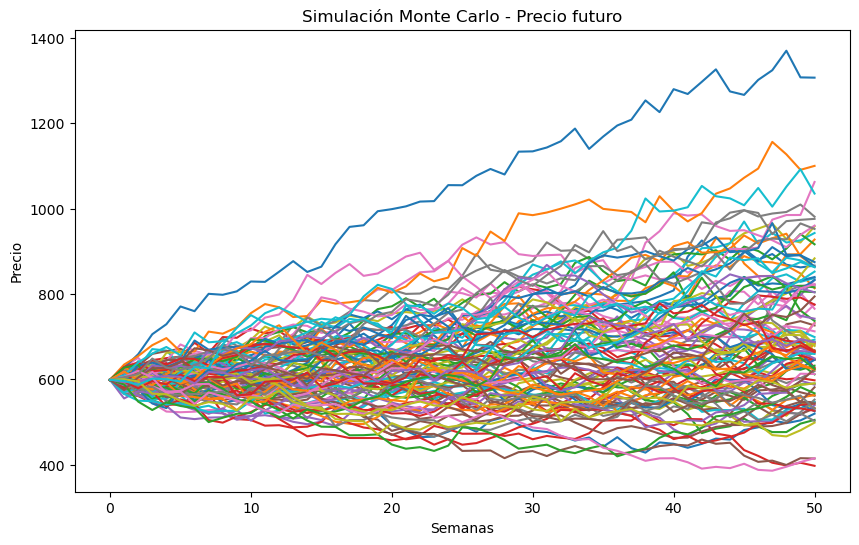

In [13]:
plt.figure(figsize=(10,6))
plt.plot(prices[:, :100])
plt.title("Simulación Monte Carlo - Precio futuro")
plt.xlabel("Semanas")
plt.ylabel("Precio")
plt.show()

**6. Redacta un análisis breve, usando markdown en tu notebook, respondiendo:**

- ¿En qué condiciones es más ventajosa la inversión periódica?

La inversión periódica (DCA) es más ventajosa cuando hay mucha incertidumbre o volatilidad en el mercado, especialmente si existe el riesgo de que el precio caiga al inicio del periodo. Al invertir poco a poco, se promedian los precios y se reduce el impacto de entrar en un mal momento. En mi simulación, aunque el rendimiento promedio fue menor que en Lump Sum, la variabilidad también fue mucho menor, lo que la hace más atractiva para inversionistas que prefieren mayor estabilidad y menos riesgo en los resultados.

- ¿Cuándo es preferible la inversión en un solo momento?

La inversión en un solo momento (Lump Sum) es preferible cuando el activo tiene una tendencia alcista clara y un rendimiento esperado positivo, como ocurrió en esta simulación con QQQ. En este caso, invertir todo desde el inicio permitió obtener un mayor valor final promedio, ya que el dinero estuvo más tiempo trabajando. Aunque implica mayor volatilidad, puede generar mejores resultados cuando el mercado mantiene un crecimiento sostenido.

